In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, distributions
import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('./data/processed/kyrbs2020_clean_v1.csv')

WEIGHT_COL = 'W'

In [2]:
value_mapping = {
    'Male': '남자', 'Female': '여자',
    'Middle school': '중학교', 'High school': '고등학교',
    'High': '상', 'Middle': '중', 'Low': '하',
    '≤3': '3시간 이하', '3 ~ 5': '3~5시간', '5 ~ 8': '5~8시간', '≥8': '8시간 이상',
    'No': '없음(아니오)', 'Yes': '있음(예)', 'Risk': '위험군',
    'Mild': '가벼움', 'Moderate': '중간', 'Severe': '심각'
}

category_order = [
    'Male', 'Female',
    'Middle school', 'High school',
    'High', 'Middle', 'Low',
    '≤3', '3 ~ 5', '5 ~ 8', '≥8',
    'No', 'Mild', 'Moderate', 'Severe', 'Risk', 'Yes'
]


def rao_scott_chi2(ct_w, weights):
    """
    Rao-Scott 1차 보정 카이제곱.
    실효 표본 수(n_eff)로 정규화 후 설계효과(DEFF)로 X²·자유도 동시 보정.
    """
    W       = weights.sum()
    n_eff   = (W ** 2) / (weights ** 2).sum()
    deff    = len(weights) / n_eff

    x2, _, dof, _ = chi2_contingency(ct_w * (n_eff / W))

    x2_rs = x2 / deff
    df_rs = max(dof / deff, 0.5)
    p_rs  = float(distributions.chi2.sf(x2_rs, df_rs))

    return x2_rs, p_rs


def generate_crosstab(df, var_col, var_name_ko, target_col, weight_col,
                      target_val_0, target_val_1, target_label_0, target_label_1):

    valid_mask = df[[var_col, target_col, weight_col]].notna().all(axis=1)
    df_valid   = df[valid_mask]
    weights    = df_valid[weight_col].values
    W_total    = weights.sum()

    ct_w = pd.crosstab(
        df_valid[var_col], df_valid[target_col],
        values=df_valid[weight_col], aggfunc='sum'
    ).fillna(0)

    x2_rs, p_rs = rao_scott_chi2(ct_w, weights)
    p_str = '< 0.001' if p_rs < 0.001 else f'{p_rs:.3f}'

    categories = sorted(
        ct_w.index.tolist(),
        key=lambda x: category_order.index(x) if x in category_order else 999
    )

    rows = []
    sum_w_0 = sum_w_1 = sum_w_total = 0

    for i, cat in enumerate(categories):
        w_0         = ct_w.loc[cat, target_val_0] if target_val_0 in ct_w.columns else 0
        w_1         = ct_w.loc[cat, target_val_1] if target_val_1 in ct_w.columns else 0
        w_cat_total = w_0 + w_1

        sum_w_0     += w_0
        sum_w_1     += w_1
        sum_w_total += w_cat_total

        cat_ratio = (w_cat_total / W_total) * 100
        pct_0     = (w_0 / w_cat_total) * 100 if w_cat_total > 0 else 0
        pct_1     = (w_1 / w_cat_total) * 100 if w_cat_total > 0 else 0

        rows.append({
            '변수'        : var_name_ko if i == 0 else '',
            '구분'        : value_mapping.get(cat, cat),
            '표본 수'     : f'{w_cat_total:,.0f} ({cat_ratio:.1f}%)',
            target_label_0: f'{w_0:,.0f} ({pct_0:.1f}%)',
            target_label_1: f'{w_1:,.0f} ({pct_1:.1f}%)',
            '검정통계량'  : f'{x2_rs:.3f}' if i == 0 else '',
            'p-value'     : p_str         if i == 0 else '',
        })

    total_r0 = (sum_w_0 / sum_w_total) * 100 if sum_w_total > 0 else 0
    total_r1 = (sum_w_1 / sum_w_total) * 100 if sum_w_total > 0 else 0
    rows.append({
        '변수'        : 'total',
        '구분'        : '',
        '표본 수'     : f'{sum_w_total:,.0f}',
        target_label_0: f'{sum_w_0:,.0f} ({total_r0:.1f}%)',
        target_label_1: f'{sum_w_1:,.0f} ({total_r1:.1f}%)',
        '검정통계량'  : '',
        'p-value'     : '',
    })

    return pd.DataFrame(rows)

In [3]:
var_mapping = {
    'gender'               : '성별',
    'school'               : '학교',
    'grade'                : '성적수준',
    'income'               : '경제수준',
    'smartphone_use_day'   : '주중 스마트폰 사용시간',
    'smartphone_use_weekend': '주말 스마트폰 사용시간',
    'smartphone_dependence' : '스마트폰 의존도',
    'sleep_quality'         : '수면 품질',
    'anxiety'               : '불안',
    'stress'                : '스트레스',
    'despair'               : '절망감',
    'suicidal_thoughts'     : '자살 생각',
}

target_col_name  = 'oral_health'
val_0, val_1     = 'No', 'Yes'
label_0, label_1 = '좋음(0)', '나쁨(1)'

final_rows = []
for col_name, kor_name in var_mapping.items():
    temp_df = generate_crosstab(
        df_clean, col_name, kor_name,
        target_col=target_col_name,
        weight_col=WEIGHT_COL,
        target_val_0=val_0,     target_val_1=val_1,
        target_label_0=label_0, target_label_1=label_1,
    )
    final_rows.append(temp_df)

df_crosstab = pd.concat(final_rows, ignore_index=True)

multi_cols = [
    ('', '변수'), ('', '구분'), ('', '표본 수'),
    (target_col_name, label_0), (target_col_name, label_1),
    ('', '검정통계량(Rao-Scott)'), ('', 'p-value'),
]
df_crosstab.columns = pd.MultiIndex.from_tuples(multi_cols)

display(df_crosstab)

df_crosstab.to_csv(
    f'./data/processed/다중인덱스_가중치교차분석표_{target_col_name}_2020.csv',
    encoding='utf-8-sig'
)

oral_health  \
              변수       구분               표본 수              좋음(0)   
0             성별       남자  1,284,529 (50.9%)    690,492 (53.8%)   
1                      여자  1,236,685 (49.1%)    561,730 (45.4%)   
2          total                   2,521,215  1,252,223 (49.7%)   
3             학교      중학교  1,262,388 (50.1%)    664,049 (52.6%)   
4                    고등학교  1,258,827 (49.9%)    588,173 (46.7%)   
5          total                   2,521,215  1,252,223 (49.7%)   
6           성적수준        상    915,590 (36.3%)    450,990 (49.3%)   
7                       중    763,919 (30.3%)    396,779 (51.9%)   
8                       하    841,706 (33.4%)    404,453 (48.1%)   
9          total                   2,521,215  1,252,223 (49.7%)   
10          경제수준        상    991,470 (39.3%)    515,559 (52.0%)   
11                      중  1,210,713 (48.0%)    601,151 (49.7%)   
12                      하    319,032 (12.7%)    135,512 (42.5%)   
13         total                   2,521,215  1,252,223 (49.7%)   
14  주중 스마트폰 사용시간   3시간 이하    979,198 (38.8%)    522,290 (53.3%)   
15                  3~5시간    788,544 (31.3%)    390,240 (49.5%)   
16                  5~8시간    476,818 (18.9%)    218,182 (45.8%)   
17                 8시간 이상    276,655 (11.0%)    121,510 (43.9%)   
18         total                   2,521,215  1,252,223 (49.7%)   
19  주말 스마트폰 사용시간   3시간 이하    517,093 (20.5%)    284,917 (55.1%)   
20                  3~5시간    655,585 (26.0%)    340,374 (51.9%)   
21                  5~8시간    688,215 (27.3%)    333,422 (48.4%)   
22                 8시간 이상    660,322 (26.2%)    293,509 (44.4%)   
23         total                   2,521,215  1,252,223 (49.7%)   
24      스마트폰 의존도  없음(아니오)  1,866,252 (74.0%)  1,021,136 (54.7%)   
25                    위험군    654,963 (26.0%)    231,087 (35.3%)   
26         total                   2,521,215  1,252,223 (49.7%)   
27         수면 품질  없음(아니오)    761,376 (30.2%)    440,816 (57.9%)   
28                  있음(예)  1,759,839 (69.8%)    811,406 (46.1%)   
29         total                   2,521,215  1,252,223 (49.7%)   
30            불안  없음(아니오)  1,675,261 (66.4%)    938,446 (56.0%)   
31                    가벼움    563,040 (22.3%)    219,494 (39.0%)   
32                     중간     194,033 (7.7%)     65,232 (33.6%)   
33                     심각      88,881 (3.5%)     29,050 (32.7%)   
34         total                   2,521,215  1,252,223 (49.7%)   
35          스트레스        상    858,585 (34.1%)    355,246 (41.4%)   
36                      중  1,125,649 (44.6%)    569,096 (50.6%)   
37                      하    536,980 (21.3%)    327,880 (61.1%)   
38         total                   2,521,215  1,252,223 (49.7%)   
39           절망감  없음(아니오)  1,890,601 (75.0%)  1,007,161 (53.3%)   
40                  있음(예)    630,614 (25.0%)    245,061 (38.9%)   
41         total                   2,521,215  1,252,223 (49.7%)   
42         자살 생각  없음(아니오)  2,249,339 (89.2%)  1,152,086 (51.2%)   
43                  있음(예)    271,875 (10.8%)    100,136 (36.8%)   
44         total                   2,521,215  1,252,223 (49.7%)   

                                                 
                나쁨(1) 검정통계량(Rao-Scott)  p-value  
0     594,037 (46.2%)          255.262  < 0.001  
1     674,955 (54.6%)                            
2   1,268,992 (50.3%)                            
3     598,338 (47.4%)          127.054  < 0.001  
4     670,654 (53.3%)                            
5   1,268,992 (50.3%)                            
6     464,600 (50.7%)           36.786  < 0.001  
7     367,140 (48.1%)                            
8     437,252 (51.9%)                            
9   1,268,992 (50.3%)                            
10    475,910 (48.0%)          127.885  < 0.001  
11    609,562 (50.3%)                            
12    183,520 (57.5%)                            
13  1,268,992 (50.3%)                            
14    456,907 (46.7%)          173.183  < 0.001  
15    398,304 (50.5%)                            
16


 [1] 다중공선성(VIF) 검증 (위계적 회귀 투입 변수 대상)


,변수명,VIF
0,주말 스마트폰 사용시간,2.109
1,주중 스마트폰 사용시간,2.068
2,불안수준,1.510
3,스트레스,1.378
4,절망감,1.360
5,자살생각,1.272
6,학업성적,1.137
7,스마트폰 의존도(위험=1),1.102
8,수면의 질(나쁨=1),1.101
9,가구소득,1.098


  ※ VIF ≥ 10: 다중공선성 위험 / ≥ 5: 주의

[model 1 (통제: 인구학적+정신건강)]


,B(회귀계수),S.E.(표준오차),OR,CI(95%),p-value
const,-0.2946,0.0044,0.7448,"(0.7385, 0.7512)",< .001 ***
성별,-0.2057,0.0026,0.8141,"(0.8099, 0.8183)",< .001 ***
학교급,0.1832,0.0026,1.2010,"(1.1948, 1.2072)",< .001 ***
학업성적,0.0555,0.0016,1.0570,"(1.0537, 1.0604)",< .001 ***
가구소득,-0.1024,0.0020,0.9027,"(0.8992, 0.9063)",< .001 ***
불안수준,0.2979,0.0020,1.3470,"(1.3416, 1.3524)",< .001 ***
스트레스,0.1740,0.0020,1.1900,"(1.1853, 1.1947)",< .001 ***
절망감,0.2187,0.0035,1.2444,"(1.2360, 1.2529)",< .001 ***
자살생각,0.0433,0.0048,1.0442,"(1.0345, 1.0541)",< .001 ***



[model 2 (+ 스마트폰 의존도/사용시간)]


,B(회귀계수),S.E.(표준오차),OR,CI(95%),p-value
const,-0.5494,0.0052,0.5773,"(0.5715, 0.5832)",< .001 ***
성별,-0.1561,0.0027,0.8555,"(0.8510, 0.8600)",< .001 ***
학교급,0.1779,0.0027,1.1948,"(1.1886, 1.2010)",< .001 ***
학업성적,0.0922,0.0017,1.0966,"(1.0930, 1.1002)",< .001 ***
가구소득,-0.0949,0.0020,0.9095,"(0.9058, 0.9131)",< .001 ***
불안수준,0.2364,0.0021,1.2667,"(1.2615, 1.2718)",< .001 ***
스트레스,0.1585,0.0020,1.1717,"(1.1671, 1.1764)",< .001 ***
절망감,0.1985,0.0035,1.2196,"(1.2113, 1.2280)",< .001 ***
자살생각,0.0324,0.0048,1.0329,"(1.0232, 1.0427)",< .001 ***
주중 스마트폰 사용시간,0.0249,0.0019,1.0252,"(1.0214, 1.0290)",< .001 ***



[model 3 (+ 수면의 질) = 최종모델]


,B(회귀계수),S.E.(표준오차),OR,CI(95%),p-value
const,-0.6675,0.0054,0.5130,"(0.5076, 0.5185)",< .001 ***
성별,-0.1472,0.0027,0.8631,"(0.8585, 0.8676)",< .001 ***
학교급,0.1592,0.0027,1.1726,"(1.1665, 1.1787)",< .001 ***
학업성적,0.0919,0.0017,1.0963,"(1.0927, 1.0999)",< .001 ***
가구소득,-0.0918,0.0020,0.9123,"(0.9086, 0.9159)",< .001 ***
불안수준,0.2284,0.0021,1.2565,"(1.2514, 1.2617)",< .001 ***
스트레스,0.1305,0.0021,1.1394,"(1.1348, 1.1440)",< .001 ***
절망감,0.1911,0.0035,1.2106,"(1.2023, 1.2189)",< .001 ***
자살생각,0.0307,0.0048,1.0312,"(1.0215, 1.0410)",< .001 ***
주중 스마트폰 사용시간,0.0238,0.0019,1.0241,"(1.0203, 1.0278)",< .001 ***



▶ 모델 비교 요약표 (Deviance·AIC·BIC 낮을수록 우수)


,투입변수수,Deviance,AIC,BIC
Block,,,,
model 1 (통제: 인구학적+정신건강),8,3385884.43,3385902.43,3386017.09
model 2 (+ 스마트폰 의존도/사용시간),11,3342569.05,3342593.05,3342745.94
model 3 (+ 수면의 질) = 최종모델,12,3336198.66,3336224.66,3336390.28


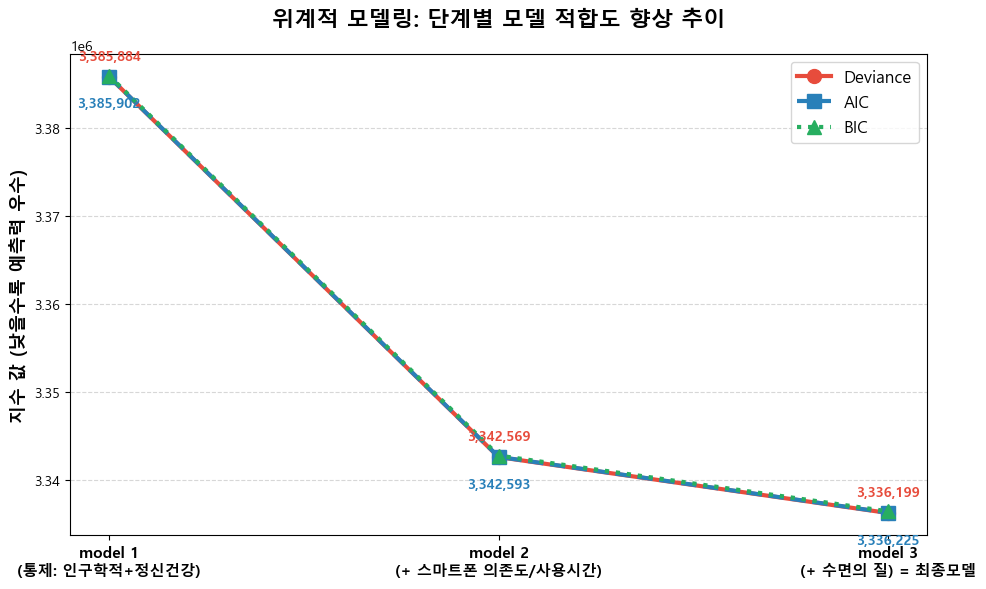

In [6]:
import os
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# 변수 그룹화 및 매핑 준비
DEMO_VARS   = ["gender", "school", "grade", "income"]
MENTAL_VARS = ["anxiety", "stress", "despair", "suicidal_thoughts"]
SP_VAR      = ["smartphone_use_day", "smartphone_use_weekend", "smartphone_dependence"]
SL_VAR      = ["sleep_quality"]
REGRESSION_FEATS = DEMO_VARS + MENTAL_VARS + SP_VAR + SL_VAR
TARGET = "oral_poor"

VAR_KOR = {
    "gender": "성별", "school": "학교급", "grade": "학업성적",
    "income": "가구소득", "anxiety": "불안수준", "stress": "스트레스",
    "despair": "절망감", "suicidal_thoughts": "자살생각",
    "smartphone_use_day"    : "주중 스마트폰 사용시간",
    "smartphone_use_weekend": "주말 스마트폰 사용시간",
    "smartphone_dependence" : "스마트폰 의존도(위험=1)",
    "sleep_quality"         : "수면의 질(나쁨=1)",
}

# 로지스틱 회귀를 위해 텍스트 범주형 데이터를 숫자로 인코딩
# (이미 EDA나 다른 전처리에서 쓰셨던 매핑 규칙 동일하게 적용)
ENCODE_MAP = {
    "gender"               : {"Female": 0, "Male": 1},
    "school"               : {"Middle school": 0, "High school": 1},
    "grade"                : {"Low": 0, "Middle": 1, "High": 2},
    "income"               : {"Low": 0, "Middle": 1, "High": 2},
    "anxiety"              : {"No": 0, "Mild": 1, "Moderate": 2, "Severe": 3},
    "stress"               : {"Low": 0, "Middle": 1, "High": 2},
    "despair"              : {"No": 0, "Yes": 1},
    "suicidal_thoughts"    : {"No": 0, "Yes": 1},
    "smartphone_use_day"   : {"≤3": 0, "3 ~ 5": 1, "5 ~ 8": 2, "≥8": 3},
    "smartphone_use_weekend": {"≤3": 0, "3 ~ 5": 1, "5 ~ 8": 2, "≥8": 3},
    "smartphone_dependence": {"No": 0, "Risk": 1},
    "sleep_quality"        : {"No": 0, "Yes": 1},
}

df_sm = df_clean.copy()
for col, mp in ENCODE_MAP.items():
    if col in df_sm.columns:
        df_sm[col] = df_sm[col].map(mp)

# 종속 변수 0, 1 인코딩
df_sm["oral_poor"] = (df_sm["oral_health"].astype(str).str.strip().str.lower() == "yes").astype(int)

# 결측치 제거 후 배열 준비
df_sm = df_sm[REGRESSION_FEATS + [TARGET, WEIGHT_COL]].dropna().reset_index(drop=True)

# ── 1. VIF 검증 (다중공선성) ──
print("\n [1] 다중공선성(VIF) 검증 (위계적 회귀 투입 변수 대상)")
X_vif  = pd.DataFrame(sm.add_constant(df_sm[REGRESSION_FEATS].astype(float)))
vif_data = pd.DataFrame({
    "변수명": [VAR_KOR.get(c, c) if c != "const" else "(상수항)" for c in X_vif.columns],
    "VIF"   : [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data["변수명"] != "(상수항)"].sort_values("VIF", ascending=False).reset_index(drop=True)
display(vif_data.round(3))
print("  ※ VIF ≥ 10: 다중공선성 위험 / ≥ 5: 주의")

# ── 2. 위계적 다중 로지스틱 회귀분석 ──
def format_pvalue(p):
    if   p < 0.001: return "< .001 ***"
    elif p < 0.01:  return f"{p:.3f} **"
    elif p < 0.05:  return f"{p:.3f} *"
    else:           return f"{p:.3f}"

w_int = np.round(df_sm[WEIGHT_COL]).astype(int)
y_sm  = df_sm[TARGET]

BLOCKS = {
    "model 1 (통제: 인구학적+정신건강)"       : DEMO_VARS + MENTAL_VARS,
    "model 2 (+ 스마트폰 의존도/사용시간)"    : DEMO_VARS + MENTAL_VARS + SP_VAR,
    "model 3 (+ 수면의 질) = 최종모델"        : DEMO_VARS + MENTAL_VARS + SP_VAR + SL_VAR,
}

fitted = {}
summary_table = []

for bname, feats in BLOCKS.items():
    X_b = sm.add_constant(df_sm[feats].astype(float))
    model_sm = sm.GLM(y_sm, X_b, family=sm.families.Binomial(), freq_weights=w_int).fit()
    fitted[bname] = model_sm

    summary_table.append({
        "Block"     : bname,
        "투입변수수": len(feats),
        "Deviance"  : round(float(model_sm.deviance), 2),
        "AIC"       : round(float(model_sm.aic), 2),
        "BIC"       : round(float(model_sm.bic_llf), 2),
    })

    print(f"\n[{bname}]")
    ci_95 = model_sm.conf_int(alpha=0.05)
    ci_95.columns = ["B_CI_Lower", "B_CI_Upper"]
    or_ci_lower = np.exp(ci_95["B_CI_Lower"])
    or_ci_upper = np.exp(ci_95["B_CI_Upper"])

    res_df_sm = pd.DataFrame({
        "B(회귀계수)"    : model_sm.params,
        "S.E.(표준오차)" : model_sm.bse,
        "OR"             : np.exp(model_sm.params),
        "CI(95%)"        : [f"({lo:.4f}, {up:.4f})" for lo, up in zip(or_ci_lower, or_ci_upper)],
        "p-value"        : model_sm.pvalues.apply(format_pvalue),
    }).round(4)
    res_df_sm.index = [VAR_KOR.get(i, i) for i in res_df_sm.index]
    display(res_df_sm)

sum_df = pd.DataFrame(summary_table).set_index("Block")
print("\n▶ 모델 비교 요약표 (Deviance·AIC·BIC 낮을수록 우수)")
display(sum_df)

# ── 3. 모델 적합도 추이 시각화 ──
OUTPUT_DIR = "./outputs_v3"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 6))
x_labels = [n.replace(" (", "\n(") for n in sum_df.index]
x        = np.arange(len(x_labels))

ax.plot(x, sum_df["Deviance"], marker="o", markersize=10, linewidth=3, label="Deviance", color="#e74c3c")
ax.plot(x, sum_df["AIC"],     marker="s", markersize=10, linewidth=3, linestyle="--", label="AIC", color="#2980b9")
ax.plot(x, sum_df["BIC"],     marker="^", markersize=10, linewidth=3, linestyle=":", label="BIC", color="#27ae60")

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=11, fontweight="bold")
ax.set_ylabel("지수 값 (낮을수록 예측력 우수)", fontsize=13, fontweight="bold")
ax.set_title("위계적 모델링: 단계별 모델 적합도 향상 추이", fontsize=16, fontweight="bold", pad=20)

# 💡 수정된 부분: ax.text() 대신 ax.annotate()를 사용하여 점 기준 '픽셀(포인트)' 단위로 고정
for i, val in enumerate(sum_df["Deviance"]):
    ax.annotate(f"{val:,.0f}", (i, val), textcoords="offset points", xytext=(0, 10), 
                ha="center", va="bottom", color="#e74c3c", fontweight="bold", fontsize=10)

for i, val in enumerate(sum_df["AIC"]):
    ax.annotate(f"{val:,.0f}", (i, val), textcoords="offset points", xytext=(0, -15), 
                ha="center", va="top", color="#2980b9", fontweight="bold", fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(fontsize=12, loc="upper right")
plt.tight_layout()
plt.show() # 주피터 노트북에 바로 표출